In [1]:
# Load the final dataset
import pandas as pd
import numpy as np

DATA_PATH = "../final_datasets/daily_stock_optimal_bucket_modeling.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38979, 80)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,...,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets,optimal_bucket
0,2006-01-03,AAPL,72.332,74.75,72.25,74.75,2.239667,28829800,0.0,1.0,...,2.444579,0.292645,0.342351,6.542020,0.272047,0.130457,0.098278,0.019956,0.005782,OTM5_30
1,2006-01-04,AAPL,75.130,75.98,74.50,74.97,2.246259,22128700,0.0,1.0,...,2.444579,0.292645,0.342351,6.561274,0.272047,0.130457,0.098278,0.019956,0.005782,OTM5_30
2,2006-01-05,AAPL,74.830,74.90,73.75,74.38,2.228582,16050800,0.0,1.0,...,2.444579,0.292645,0.342351,6.509638,0.272047,0.130457,0.098278,0.019956,0.005782,OTM5_30
3,2006-01-06,AAPL,75.240,76.70,74.55,76.30,2.286109,25159200,0.0,1.0,...,2.444579,0.292645,0.342351,6.677673,0.272047,0.130457,0.098278,0.019956,0.005782,OTM5_30
4,2006-01-09,AAPL,76.730,77.20,75.74,76.05,2.278618,24108600,0.0,1.0,...,2.444579,0.292645,0.342351,6.655794,0.272047,0.130457,0.098278,0.019956,0.005782,OTM5_30


In [2]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['date', 'symbol', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividend', 'split_coeff', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'operatingExpenses', 'ebit', 'ebitda', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'totalLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'totalShareholderEquity', 'commonStockSharesOutstanding', 'operatingCashflow', 'capitalExpenditures', 'cashflowFromInvestment', 'cashflowFromFinancing', 'dividendPayout', 'netIncome', 'MarketCapitalization', 'PERatio', 'BookValue', 'DividendYield', 'EPS', 'RevenueTTM', 'ProfitMargin', 'OperatingMarginTTM', 'ReturnOnAssetsTTM', 'ReturnOnEquityTTM', 'Beta', '52WeekHigh', '52WeekLow', '50DayMovingAverage', '200DayMovingAverage', 'SharesOutstanding', 'return_1d', 'log_return', 'momentum_1m', 'momentum_3m', 'momentum_6m', 'ma_20', 'ma_50', 'ma_200', 'price_vs_ma50', 'price_vs_ma200', 'vol_20', 'vol_60', 'parkinson_daily', 'parkinson_vol

In [3]:
df.select_dtypes(include=["object"]).columns

Index(['symbol', 'optimal_bucket'], dtype='object')

In [4]:
# Sort data by symbol and date. Very important for time series models
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["symbol","date"]).reset_index(drop=True)

In [5]:
# duplicate check
duplicates = df.duplicated(subset=["symbol","date"]).sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [6]:
#Null value check
null_summary = df.isnull().sum().sort_values(ascending=False)

null_summary = null_summary[null_summary > 0]

print(null_summary)

Series([], dtype: int64)


In [7]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df["optimal_bucket_encoded"] = target_encoder.fit_transform(df["optimal_bucket"])

In [8]:
mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))

print(mapping)

{'ATM_30': np.int64(0), 'ATM_60': np.int64(1), 'ATM_90': np.int64(2), 'OTM10_30': np.int64(3), 'OTM10_60': np.int64(4), 'OTM10_90': np.int64(5), 'OTM5_30': np.int64(6), 'OTM5_60': np.int64(7), 'OTM5_90': np.int64(8)}


In [10]:
# apply one hot encoding on symbol

# apply one hot encoding on symbol
df_encoded = pd.get_dummies(
    df,
    columns=["symbol"],
    prefix="symbol"
)

# get symbol columns
symbol_cols = [col for col in df_encoded.columns if col.startswith("symbol_")]

print("Encoded symbol columns:")
print(symbol_cols)

# convert True/False → 1/0
df_encoded[symbol_cols] = df_encoded[symbol_cols].astype(int)

# preview
df_encoded[symbol_cols].head()

# check datatype
df_encoded[symbol_cols].dtypes

Encoded symbol columns:
['symbol_AAPL', 'symbol_ADMA', 'symbol_AMZN', 'symbol_AXON', 'symbol_GOOG', 'symbol_META', 'symbol_MSFT', 'symbol_NTRA', 'symbol_NVDA', 'symbol_SHAK']


symbol_AAPL    int64
symbol_ADMA    int64
symbol_AMZN    int64
symbol_AXON    int64
symbol_GOOG    int64
symbol_META    int64
symbol_MSFT    int64
symbol_NTRA    int64
symbol_NVDA    int64
symbol_SHAK    int64
dtype: object

In [11]:

df_encoded[symbol_cols].head()

,symbol_AAPL,symbol_ADMA,symbol_AMZN,symbol_AXON,symbol_GOOG,symbol_META,symbol_MSFT,symbol_NTRA,symbol_NVDA,symbol_SHAK
0,1,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


In [12]:
df_encoded[symbol_cols].dtypes

symbol_AAPL    int64
symbol_ADMA    int64
symbol_AMZN    int64
symbol_AXON    int64
symbol_GOOG    int64
symbol_META    int64
symbol_MSFT    int64
symbol_NTRA    int64
symbol_NVDA    int64
symbol_SHAK    int64
dtype: object

In [13]:
# verify exactly one symbol per row
df_encoded[symbol_cols].sum(axis=1).value_counts()

1    38979
Name: count, dtype: int64

In [14]:
df_encoded = df_encoded.sort_values(symbol_cols + ["date"])

In [15]:
df_encoded.tail()

,date,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,...,symbol_AAPL,symbol_ADMA,symbol_AMZN,symbol_AXON,symbol_GOOG,symbol_META,symbol_MSFT,symbol_NTRA,symbol_NVDA,symbol_SHAK
5026,2025-12-24,272.34,275.43,272.195,273.81,273.551012,17910574,0.0,1.0,2025-09-30,...,1,0,0,0,0,0,0,0,0,0
5027,2025-12-26,274.16,275.37,272.860,273.40,273.141400,21521802,0.0,1.0,2025-09-30,...,1,0,0,0,0,0,0,0,0,0
5028,2025-12-29,272.69,274.36,272.350,273.76,273.501059,23715213,0.0,1.0,2025-09-30,...,1,0,0,0,0,0,0,0,0,0
5029,2025-12-30,272.81,274.08,272.280,273.08,272.821703,22139617,0.0,1.0,2025-09-30,...,1,0,0,0,0,0,0,0,0,0
5030,2025-12-31,273.06,273.68,271.750,271.86,271.602857,27293639,0.0,1.0,2025-12-31,...,1,0,0,0,0,0,0,0,0,0


In [16]:
# covert fiscalddf["fiscalDateEnding"] = pd.to_datetime(df["fiscalDateEnding"])
df_encoded["date"] = pd.to_datetime(df_encoded["date"])

df_encoded["days_since_fiscal_report"] = (
    df_encoded["date"] - df_encoded["fiscalDateEnding"]
).dt.days

# quarter feature
df_encoded["fiscal_quarter"] = df_encoded["fiscalDateEnding"].dt.quarter


# drop raw fiscal date
df_encoded = df_encoded.drop(columns=["fiscalDateEnding"])

In [22]:
df_encoded.head()

,date,open,high,low,close,adj_close,volume,dividend,split_coeff,totalRevenue,...,symbol_AMZN,symbol_AXON,symbol_GOOG,symbol_META,symbol_MSFT,symbol_NTRA,symbol_NVDA,symbol_SHAK,days_since_fiscal_report,fiscal_quarter
36431,2015-11-12,44.49,45.1800,42.13,42.47,42.47,1003149,0.0,1.0,53273000.0,...,0,0,0,0,0,0,0,1,43,3
36432,2015-11-13,42.00,42.3600,39.91,40.85,40.85,1249843,0.0,1.0,53273000.0,...,0,0,0,0,0,0,0,1,44,3
36433,2015-11-16,40.70,43.8000,39.95,43.42,43.42,1007557,0.0,1.0,53273000.0,...,0,0,0,0,0,0,0,1,47,3
36434,2015-11-17,43.00,43.5100,41.57,42.96,42.96,699699,0.0,1.0,53273000.0,...,0,0,0,0,0,0,0,1,48,3
36435,2015-11-18,42.71,43.8548,41.77,42.48,42.48,536856,0.0,1.0,53273000.0,...,0,0,0,0,0,0,0,1,49,3


In [17]:
# Build df_final

# selected top 50 features
top_50_features = [
    "rolling_max",
    "ma_200",
    "gross_margin",
    "ma_50",
    "book_value_per_share_proxy",
    "ma_20",
    "asset_to_liability",
    "commonStockSharesOutstanding",
    "totalLiabilities",
    "longTermDebt",
    "high",
    "low",
    "close",
    "totalAssets",
    "open",
    "52WeekLow",
    "EPS",
    "adj_close",
    "totalShareholderEquity",
    "totalCurrentAssets",
    "200DayMovingAverage",
    "operatingExpenses",
    "grossProfit",
    "totalRevenue",
    "debt_to_equity",
    "50DayMovingAverage",
    "totalCurrentLiabilities",
    "BookValue",
    "volume_ma20",
    "capitalExpenditures",
    "PERatio",
    "vol_60",
    "operatingIncome",
    "SharesOutstanding",
    "ebitda",
    "ebit",
    "cashAndCashEquivalentsAtCarryingValue",
    "cashflowFromFinancing",
    "price_to_book_proxy",
    "cash_to_assets",
    "operating_margin_calc",
    "netIncome",
    "dividendPayout",
    "Beta",
    "52WeekHigh",
    "operatingCashflow",
    "net_margin_calc",
    "RevenueTTM",
    "capex_to_assets",
    "operating_cf_to_assets"
]

# symbol one-hot columns
symbol_cols = [col for col in df_encoded.columns if col.startswith("symbol_")]

# extra columns you want to keep
extra_cols = [
    "days_since_fiscal_report",
    "fiscal_quarter",
    "date",
    "optimal_bucket_encoded"
]

# final column list
final_cols = top_50_features + ["days_since_fiscal_report", "fiscal_quarter"] + symbol_cols + ["date", "optimal_bucket_encoded"]

# keep only columns that actually exist
final_cols = [col for col in final_cols if col in df_encoded.columns]

df_final = df_encoded[final_cols].copy()

# sort by date for time-based split
df_final["date"] = pd.to_datetime(df_final["date"])
# sort by symbol columns first, then date
df_final = df_final.sort_values(symbol_cols + ["date"]).reset_index(drop=True)

print("df_final shape:", df_final.shape)
print(df_final.head())

df_final shape: (38979, 64)
   rolling_max    ma_200  gross_margin    ma_50  book_value_per_share_proxy  \
0        92.86  55.46645      0.491206  47.5128                    4.331559   
1        92.86  55.44120      0.491206  47.3676                    4.331559   
2        92.86  55.43835      0.491206  47.2798                    4.331559   
3        92.86  55.42825      0.491206  47.1536                    4.331559   
4        92.86  55.43405      0.491206  47.0332                    4.331559   

     ma_20  asset_to_liability  commonStockSharesOutstanding  \
0  45.7500            1.735984                    36250000.0   
1  45.6195            1.735984                    36250000.0   
2  45.5760            1.735984                    36250000.0   
3  45.5235            1.735984                    36250000.0   
4  45.5310            1.735984                    36250000.0   

   totalLiabilities  longTermDebt  ...  symbol_AMZN  symbol_AXON  symbol_GOOG  \
0       222528000.0      313000

In [18]:
# check for duplicates and nulls
print("Full-row duplicates:", df_final.duplicated().sum())

null_summary = df_final.isnull().sum().sort_values(ascending=False)
print("\nColumns with nulls:")
print(null_summary[null_summary > 0])

Full-row duplicates: 0

Columns with nulls:
Series([], dtype: int64)


### TRAIN + VAL + TEST splits

In [27]:
train_df = df_final[df_final["date"] < "2022-01-01"].copy()

val_df = df_final[
    (df_final["date"] >= "2022-01-01") &
    (df_final["date"] < "2024-01-01")
].copy()

test_df = df_final[df_final["date"] >= "2024-01-01"].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Val date range:", val_df["date"].min(), "to", val_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

Train shape: (28949, 64)
Val shape: (5010, 64)
Test shape: (5020, 64)

Train date range: 2006-01-03 00:00:00 to 2021-12-31 00:00:00
Val date range: 2022-01-03 00:00:00 to 2023-12-29 00:00:00
Test date range: 2024-01-02 00:00:00 to 2025-12-31 00:00:00


### Build X and y while preserving alignment

In [28]:
# y first
y_train = train_df["optimal_bucket_encoded"].copy()
y_val   = val_df["optimal_bucket_encoded"].copy()
y_test  = test_df["optimal_bucket_encoded"].copy()

# X after dropping date and target
X_train = train_df.drop(columns=["date", "optimal_bucket_encoded"]).copy()
X_val   = val_df.drop(columns=["date", "optimal_bucket_encoded"]).copy()
X_test  = test_df.drop(columns=["date", "optimal_bucket_encoded"]).copy()

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (28949, 62) y_train: (28949,)
X_val: (5010, 62) y_val: (5010,)
X_test: (5020, 62) y_test: (5020,)


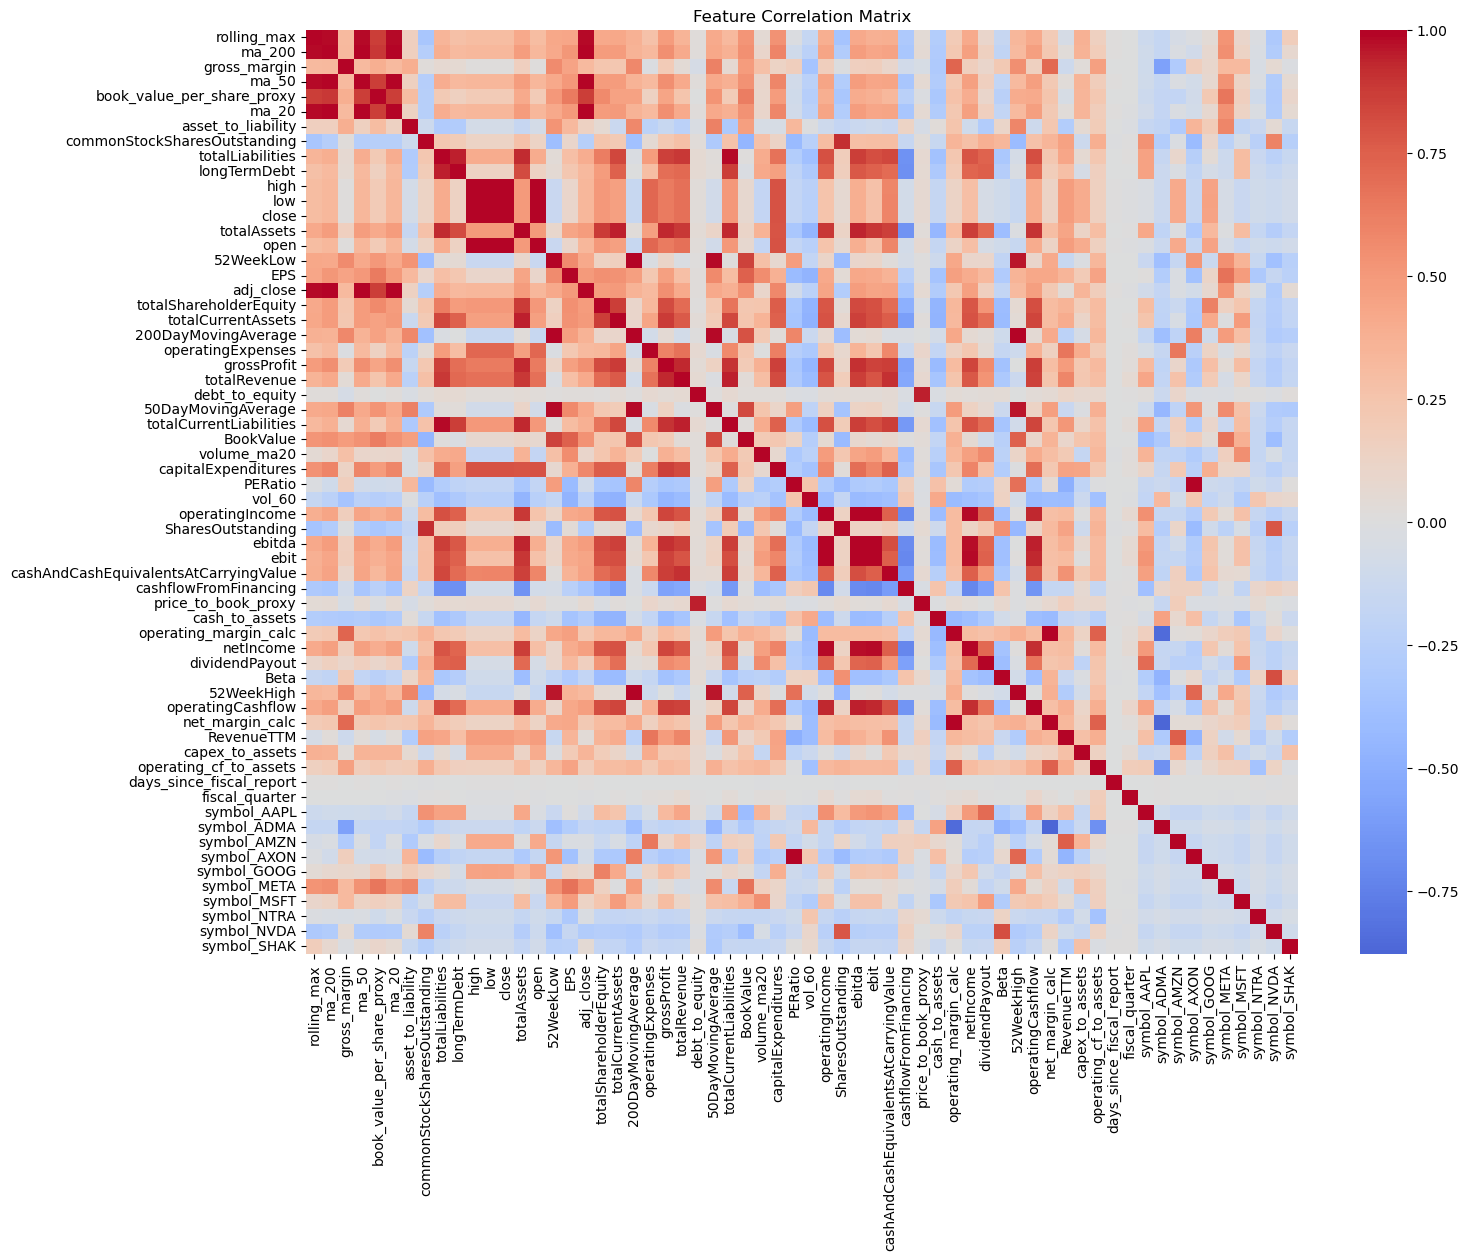

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [34]:
corr_threshold = 0.99

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(abs(upper_triangle[column]) > corr_threshold)
]

print("Highly correlated features:")
print(high_corr_features)
print("Total:", len(high_corr_features))

Highly correlated features:
['ma_50', 'ma_20', 'low', 'close', 'open', 'adj_close', 'ebit', '52WeekHigh', 'net_margin_calc', 'symbol_AXON']
Total: 10


In [35]:
features_to_drop = [
    col for col in high_corr_features
    if col != "symbol_AXON"
]

print("Dropping features:", features_to_drop)

Dropping features: ['ma_50', 'ma_20', 'low', 'close', 'open', 'adj_close', 'ebit', '52WeekHigh', 'net_margin_calc']


In [36]:
X_train = X_train.drop(columns=features_to_drop, errors="ignore")
X_val   = X_val.drop(columns=features_to_drop, errors="ignore")
X_test  = X_test.drop(columns=features_to_drop, errors="ignore")

print("New dataset shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

New dataset shapes:
X_train: (28949, 53)
X_val: (5010, 53)
X_test: (5020, 53)


### Perform Standard scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [38]:
# convert back to dataframe

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [39]:
# verify scaling
# 
X_train_scaled.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
rolling_max,28949.0,-1.570857e-17,1.000017,-0.831428,-0.641728,-0.368733,0.332651,5.090702
ma_200,28949.0,-8.639713e-17,1.000017,-0.755783,-0.664292,-0.384472,0.275719,5.549329
gross_margin,28949.0,1.806485e-16,1.000017,-7.637254,-0.263777,0.145983,0.515524,1.269475
book_value_per_share_proxy,28949.0,4.712571e-17,1.000017,-0.873818,-0.659651,-0.344172,0.368860,5.562832
asset_to_liability,28949.0,0.000000e+00,1.000017,-1.098219,-0.668791,-0.357379,0.287768,5.114278


### save the model datasets into separate folder

In [40]:
from pathlib import Path

MODEL_DATA_PATH = Path("../model_datasets")
MODEL_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("Folder created:", MODEL_DATA_PATH)

Folder created: ../model_datasets


In [41]:
X_train_scaled.to_parquet(MODEL_DATA_PATH / "X_train_scaled.parquet", index=False)
X_val_scaled.to_parquet(MODEL_DATA_PATH / "X_val_scaled.parquet", index=False)
X_test_scaled.to_parquet(MODEL_DATA_PATH / "X_test_scaled.parquet", index=False)

print("Feature datasets saved")

Feature datasets saved


In [42]:
y_train.to_frame(name="optimal_bucket_encoded").to_parquet(
    MODEL_DATA_PATH / "y_train.parquet", index=False
)

y_val.to_frame(name="optimal_bucket_encoded").to_parquet(
    MODEL_DATA_PATH / "y_val.parquet", index=False
)

y_test.to_frame(name="optimal_bucket_encoded").to_parquet(
    MODEL_DATA_PATH / "y_test.parquet", index=False
)

print("Target datasets saved")

Target datasets saved


In [43]:
list(MODEL_DATA_PATH.glob("*"))

[PosixPath('../model_datasets/X_val_scaled.parquet'),
 PosixPath('../model_datasets/y_train.parquet'),
 PosixPath('../model_datasets/X_test_scaled.parquet'),
 PosixPath('../model_datasets/y_test.parquet'),
 PosixPath('../model_datasets/y_val.parquet'),
 PosixPath('../model_datasets/X_train_scaled.parquet')]

In [46]:
print(X_train_scaled.columns.tolist())

['rolling_max', 'ma_200', 'gross_margin', 'book_value_per_share_proxy', 'asset_to_liability', 'commonStockSharesOutstanding', 'totalLiabilities', 'longTermDebt', 'high', 'totalAssets', '52WeekLow', 'EPS', 'totalShareholderEquity', 'totalCurrentAssets', '200DayMovingAverage', 'operatingExpenses', 'grossProfit', 'totalRevenue', 'debt_to_equity', '50DayMovingAverage', 'totalCurrentLiabilities', 'BookValue', 'volume_ma20', 'capitalExpenditures', 'PERatio', 'vol_60', 'operatingIncome', 'SharesOutstanding', 'ebitda', 'cashAndCashEquivalentsAtCarryingValue', 'cashflowFromFinancing', 'price_to_book_proxy', 'cash_to_assets', 'operating_margin_calc', 'netIncome', 'dividendPayout', 'Beta', 'operatingCashflow', 'RevenueTTM', 'capex_to_assets', 'operating_cf_to_assets', 'days_since_fiscal_report', 'fiscal_quarter', 'symbol_AAPL', 'symbol_ADMA', 'symbol_AMZN', 'symbol_AXON', 'symbol_GOOG', 'symbol_META', 'symbol_MSFT', 'symbol_NTRA', 'symbol_NVDA', 'symbol_SHAK']
